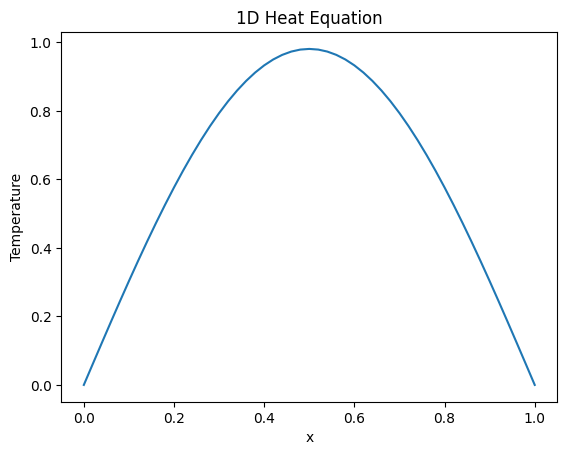

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
L = 1.0          # Length of rod
T = 0.2          # Total simulation time
alpha = 0.01     # Thermal diffusivity

nx = 51
dx = L / (nx - 1)

dt = 0.4 * dx**2 / alpha      # Stable choice (r <= 0.5)
nt = int(T / dt)

r = alpha * dt / dx**2

# Grid
x = np.linspace(0, L, nx)

# Initial condition: sine wave
u = np.sin(np.pi * x)
u_new = u.copy()

# Time stepping
for n in range(nt):
    for i in range(1, nx - 1):
        u_new[i] = u[i] + r * (u[i+1] - 2*u[i] + u[i-1])

    # Dirichlet boundaries
    u_new[0] = 0
    u_new[-1] = 0

    u[:] = u_new

# Plot
plt.plot(x, u)
plt.xlabel("x")
plt.ylabel("Temperature")
plt.title("1D Heat Equation")
plt.show()